# Phase 23 — FGSM Evasion Attack (Attack D only): WISDM

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification

## Scope of this notebook

This notebook evaluates **only the FGSM evasion attack** (Attack D from Phase 22) — no membership
inference, no other attack families — across **all 8 continual-learning strategies** on **WISDM**:

`Std 0%`, `Std 15%`, `CDML`, `CDML+KD`, `WGR-CDML`, `LiDER`, `CDML+LoRA`, `WGR-CDML+LoRA`

Model, training, and data-loading code is reused verbatim from `phase11_unified_security_evaluation_wisdm.ipynb` (Std/CDML/CDML+KD/WGR-CDML/LiDER)
and `phase15_lora_comparison_wisdm.ipynb` (CDML+LoRA/WGR-CDML+LoRA) — nothing about the underlying models has been changed.

### One correction relative to Phase 22's model list

**LiDER is CDML-based**, not a separate mechanism: its training function builds a `GaitCNN_CDML` and adds
10% experience replay plus a Lipschitz spectral-norm penalty (Bonicelli et al., NeurIPS 2022) on top. It
therefore has a real CDML seed that can be attacked/withheld, unlike the two `Std` baselines, which have no
privacy mechanism of any kind.

### Attacker conditions, per model

Not every model has something to withhold, so the attacker-condition matrix now has three tiers:

| Model | CDML seed? | LoRA adapter? | conditions tested |
|---|---|---|---|
| Std 0%, Std 15% | no | no | `oracle` only |
| CDML, CDML+KD, WGR-CDML, LiDER | yes | no | `oracle`, `no_seed` |
| CDML+LoRA, WGR-CDML+LoRA | yes | yes | `oracle`, `no_seed`, `no_adapter`, `no_seed_no_adapter` |

### Methodology (unchanged from Phase 22's fixed version)

Attack D is a **transfer attack**: the query population (windows correctly classified by the real, `oracle`
-configured system) is fixed once per task; the FGSM perturbation is crafted using whichever model copy the
attacker's condition gives them access to; success is always evaluated against the **oracle** model's
prediction, since that is what a deployed system actually uses to grant or deny access.

### Epoch/LR consistency

The two source notebooks for this dataset didn't always agree on `EPOCHS`/`LR_DECAY` (the Std/CDML/KD/WGR/LiDER
notebook and the LoRA notebook were written at different times). Per your instruction, both are pinned to a
single value here so all 8 models are trained under an identical budget: `EPOCHS=100`, `LR_DECAY=0.98`.


## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset, Subset
)
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

try:
    import pywt
    PYWT_AVAILABLE = True
    print('PyWavelets available — using DWT decomposition')
except ImportError:
    PYWT_AVAILABLE = False
    print('PyWavelets not found — using FFT fallback for WGR')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

PyWavelets available — using DWT decomposition
Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [2]:
# ── Dataset path ─────────────────────────────────────────────────────────────
# Expected structure under DATA_DIR:
#   raw/phone/accel/data_16XX_accel_phone.txt
#   raw/phone/gyro/data_16XX_gyro_phone.txt
DATA_DIR = "../Data/wisdm-dataset"

# ── Sensor / window settings ──────────────────────────────────────────────────
N_CHANNELS      = 6    # phone-accel (x,y,z) + phone-gyro (x,y,z)
WINDOW_SIZE     = 200  # 10 s × 20 Hz = 200 samples
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 51   # 51 subjects (1600–1650, re-indexed 1–51)
CDML_SEED_BASE  = 1000

EPOCHS   = 100   # pinned consistent across all 8 models (was mismatched between source notebooks)
LR_INIT  = 1e-3
LR_DECAY = 0.98

# 51 subjects split roughly equally across 4 tasks
TASK_SPLITS = {
    'Task 1': (1,  13),   # subjects  1–13
    'Task 2': (14, 26),   # subjects 14–26
    'Task 3': (27, 39),   # subjects 27–39
    'Task 4': (40, 51),   # subjects 40–51
}

# ── Model hyperparameters ─────────────────────────────────────────────────────
STD_REPLAY_FRAC  = 0.15   # Std 15% model

# CDML+KD (focal distillation)
KD_LAMBDA        = 0.001
KD_ALPHA         = 0.0    # focal: 0 = only penalise correct-sample divergence
KD_BETA          = 1.0
KD_MEMORY_FRAC   = 0.20

# WGR-CDML (Wavelet Generative Replay)
WGR_WAVELET      = 'db4'
WGR_LEVEL        = 3
WGR_N_SYNTH      = 30
WGR_JITTER_STD   = 0.05

# LiDER (Lipschitz-Driven Experience Replay)
LIDER_REPLAY_FRAC = 0.10
LIDER_WEIGHT      = 0.01
LIDER_KAPPA       = 2.0

# ── Attack A — IIA ────────────────────────────────────────────────────────────
IIA_N_QUERIES    = 20
IIA_AGGREGATION  = 'mean'

# ── Attack B — Feature Space Inference ───────────────────────────────────────
KNN_K            = 5

# ── Attack C — Backdoor ───────────────────────────────────────────────────────
# 0-indexed label for a Task 4 subject (subject 45 → re-indexed ID 45 → label idx 44)
BACKDOOR_TARGET_IDX  = 44
BACKDOOR_POISON_FRAC = 0.15
BACKDOOR_TRIGGER_AMP = 0.5
BACKDOOR_TRIGGER_FREQ = 8
BACKDOOR_TRIGGER_CH  = 2     # acc_z channel

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

# ── LoRA hyperparameters (from the LoRA source notebook) ─────────────────
LORA_RANK  = 8
LORA_ALPHA = 8

# ── Attack D — FGSM evasion configuration ─────────────────────────────────
NO_SEED_ATTACKER_SEED   = 27     # arbitrary wrong seed (a real ±1 sequence, NOT zeroed --
                                  # zeroing would make CDML gradients identically 0, which
                                  # would make FGSM degenerate rather than reveal anything)
FGSM_EVASION_EPSILONS   = [0.05, 0.1, 0.2, 0.3, 0.5]     # ASR-vs-epsilon sweep
FGSM_EVASION_N_PER_TASK = None   # None = use full test split per task


Configuration set.


## 2. Data loading

In [3]:
import os

# ─────────────────────────────────────────────────────────────────────────────
# Helper: read one sensor directory (phone/accel or phone/gyro)
# Each file:  subject_id, activity_code, timestamp, x, y, z;
# ─────────────────────────────────────────────────────────────────────────────
def load_wisdm_sensor(data_dir, sensor_type):
    """Read all per-subject raw files for one phone sensor.

    Returns
    -------
    dict: {subject_id (int) -> {'activity': list[str], 'x': list, 'y': list, 'z': list}}
    """
    subdir = os.path.join(data_dir, 'raw', 'phone', sensor_type)
    sensor_data = {}
    for fname in sorted(os.listdir(subdir)):
        if not fname.endswith('.txt'):
            continue
        # filename pattern: data_16XX_accel_phone.txt
        subj_id = int(fname.split('_')[1])
        rows = {'activity': [], 'x': [], 'y': [], 'z': []}
        with open(os.path.join(subdir, fname)) as fh:
            for line in fh:
                line = line.strip().rstrip(';').strip()
                if not line:
                    continue
                parts = line.split(',')
                if len(parts) < 6:
                    continue
                try:
                    rows['activity'].append(parts[1].strip())
                    rows['x'].append(float(parts[3]))
                    rows['y'].append(float(parts[4]))
                    rows['z'].append(float(parts[5]))
                except (ValueError, IndexError):
                    pass   # skip malformed lines
        sensor_data[subj_id] = rows
    return sensor_data


def load_wisdm_walking(data_dir, window_size=200):
    """Load non-overlapping walking windows from WISDM phone accel + gyro.

    WISDM subjects 1600–1650 are re-indexed to 1–51 so that TASK_SPLITS
    (which reference IDs 1–51) work without modification.

    Returns
    -------
    X        : np.ndarray  shape (N, 6, window_size)  — channels: ax,ay,az,gx,gy,gz
    subjects : np.ndarray  shape (N,)                 — re-indexed subject IDs 1–51
    """
    print('Loading WISDM phone-accel...')
    accel = load_wisdm_sensor(data_dir, 'accel')
    print('Loading WISDM phone-gyro...')
    gyro  = load_wisdm_sensor(data_dir, 'gyro')

    # Intersect subjects present in both sensors and sort for stable re-indexing
    common_ids = sorted(set(accel.keys()) & set(gyro.keys()))
    reindex    = {sid: i + 1 for i, sid in enumerate(common_ids)}  # 1600→1, …, 1650→51
    print(f'Subjects found: {len(common_ids)}  ({common_ids[0]}–{common_ids[-1]})')

    X_list, subj_list = [], []

    for sid in common_ids:
        a = accel[sid]
        g = gyro[sid]

        # Extract contiguous walking (activity == 'A') readings
        a_xyz = [(x, y, z) for act, x, y, z
                 in zip(a['activity'], a['x'], a['y'], a['z']) if act == 'A']
        g_xyz = [(x, y, z) for act, x, y, z
                 in zip(g['activity'], g['x'], g['y'], g['z']) if act == 'A']

        if not a_xyz or not g_xyz:
            print(f'  WARNING: no walking data for subject {sid}, skipping.')
            continue

        # Trim to the shorter of the two sensor streams, then window
        min_len   = min(len(a_xyz), len(g_xyz))
        n_windows = min_len // window_size
        if n_windows == 0:
            print(f'  WARNING: subject {sid} has <{window_size} walking samples, skipping.')
            continue

        ax = [v[0] for v in a_xyz[:n_windows * window_size]]
        ay = [v[1] for v in a_xyz[:n_windows * window_size]]
        az = [v[2] for v in a_xyz[:n_windows * window_size]]
        gx = [v[0] for v in g_xyz[:n_windows * window_size]]
        gy = [v[1] for v in g_xyz[:n_windows * window_size]]
        gz = [v[2] for v in g_xyz[:n_windows * window_size]]

        for i in range(n_windows):
            s, e = i * window_size, (i + 1) * window_size
            window = np.array([
                ax[s:e], ay[s:e], az[s:e],   # accel channels 0-2
                gx[s:e], gy[s:e], gz[s:e],   # gyro  channels 3-5
            ], dtype=np.float32)              # shape (6, 200)
            X_list.append(window)
            subj_list.append(reindex[sid])

    X        = np.stack(X_list)            # (N, 6, 200)
    subjects = np.array(subj_list, int)    # (N,)  IDs 1–51
    return X, subjects


# --- 1. Load WISDM walking windows (activity 'A', phone accel + gyro) ---------
X_walk, y_walk = load_wisdm_walking(DATA_DIR, WINDOW_SIZE)
print(f'Walking windows: {X_walk.shape}  |  unique subjects: {len(np.unique(y_walk))}')

# --- 2. Per-subject 85 / 15 window split --------------------------------------
# Splitting windows within each subject guarantees that every subject
# contributes samples to both train and test — a requirement for
# continual gait identification and membership-inference evaluation.
rng_np         = np.random.default_rng(RANDOM_SEED)
tr_idx, te_idx = [], []
for subj in np.unique(y_walk):
    idx = np.where(y_walk == subj)[0]
    rng_np.shuffle(idx)
    cut = max(1, int(len(idx) * (1.0 - VAL_SPLIT)))   # ~85 % train
    tr_idx.extend(idx[:cut].tolist())
    te_idx.extend(idx[cut:].tolist())

tr_idx = np.array(tr_idx)
te_idx = np.array(te_idx)

X_train, y_train_subj = X_walk[tr_idx], y_walk[tr_idx]
X_test,  y_test_subj  = X_walk[te_idx], y_walk[te_idx]

# --- 3. Normalise — fit statistics on training windows only -------------------
ch_mean = X_train.mean(axis=(0, 2), keepdims=True)   # (1, 6, 1)
ch_std  = X_train.std( axis=(0, 2), keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

# --- 4. Build 0-indexed PyTorch labels ----------------------------------------
unique_labels = np.sort(np.unique(y_walk))            # all 51 subjects
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train_subj])
y_test_idx    = np.array([label_to_idx[l] for l in y_test_subj])

# --- 5. Build per-task datasets -----------------------------------------------
def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr  = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full  = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(
            torch.tensor(X_te[mask_te]),
            torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds):>4} train | {n_val:>3} val | {len(test_ds):>4} test')
    return task_data

print('\nBuilding Continual Learning Tasks (Walking Only)...')
task_data  = make_task_datasets(
    X_train_norm, y_train_subj, y_train_idx,
    X_test_norm,  y_test_subj,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED)

task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'\nTrain pool : {X_train.shape}')
print(f'Test  pool : {X_test.shape}')


Loading WISDM phone-accel...
Loading WISDM phone-gyro...
Subjects found: 51  (1600–1650)
Walking windows: (984, 6, 200)  |  unique subjects: 51

Building Continual Learning Tasks (Walking Only)...
Task 1:  169 train |  29 val |   43 test
Task 2:  175 train |  30 val |   44 test
Task 3:  168 train |  29 val |   42 test
Task 4:  178 train |  31 val |   46 test

Train pool : (809, 6, 200)
Test  pool : (175, 6, 200)


## 3. Model definitions

In [4]:
# ── Shared backbone ───────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)

class GaitCNN(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)
    def embed(self, x): return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))

# ── CDML layer and model ──────────────────────────────────────────────────────
def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))

class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence

class GaitCNN_CDML(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}
    def embed_raw(self, x):        return self.backbone.embed(x)
    def embed_modulated(self, x):  return self.cdml(self.backbone.embed(x))
    def forward(self, x):          return self.backbone.classifier(self.cdml(self.backbone.embed(x)))
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)
    def zero_sequence(self):
        """Attacker without seed: zeroes all embeddings."""
        self.cdml.sequence = torch.zeros(
            self.embed_dim, device=next(self.parameters()).device)

# ── Shared utilities ──────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    c, t = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        c += (model(X_b).argmax(1) == y_b).sum().item()
        t += len(y_b)
    return c / t

def make_replay_subset(dataset, frac, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n   = len(dataset)
    k   = max(1, int(n * frac))
    idx = rng.choice(n, k, replace=False).tolist()
    Xs, ys = zip(*[dataset[i] for i in idx])
    return TensorDataset(torch.stack(Xs), torch.stack(ys))

print(f'GaitCNN params: {sum(p.numel() for p in GaitCNN(N_CHANNELS,N_CLASSES_TOTAL,EMBED_DIM).parameters()):,}')
print('Model classes defined.')

GaitCNN params: 284,115
Model classes defined.


### 3.2 LoRA linear layer

In [5]:
class LoRALinear(nn.Module):
    """
    Linear layer augmented with Low-Rank Adaptation (Hu et al. 2021).

    Forward pass:  y = W·x + b  +  (B_k · A_k)·x  × (alpha / rank)
    ─────────────────────────────────────────────────────────────────
    W (base weight) is frozen after the first task.
    A_k, B_k are task-specific adapters (reinitialised per task, then saved).

    Parameter budget:
        Standard Linear(d_in, d_out):  d_in × d_out
        LoRALinear adapter per task:   rank × (d_in + d_out)   ≪  d_in × d_out  for typical ranks

    For rank=8, EMBED_DIM=128:
        embedding LoRA: 8×(flat+128)   vs   flat×128
        classifier LoRA: 8×(128+118)   vs   128×118 = 15 104 params

    Privacy note: the frozen base W captures cross-task gait structure.
    Task-specific memorisation is confined to the small adapter matrices,
    which are kept private alongside the CDML seed.
    """
    def __init__(self, in_features, out_features, rank=LORA_RANK,
                 alpha=LORA_ALPHA, bias=True):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.rank    = rank
        self.alpha   = alpha
        self.scaling = alpha / rank

        # Base weight — shared across tasks, frozen after task 1
        self.weight = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty(out_features, in_features),
                                     a=np.sqrt(5)))
        if bias:
            fan_in = in_features
            bound  = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
            self.bias = nn.Parameter(
                torch.empty(out_features).uniform_(-bound, bound))
        else:
            self.register_parameter('bias', None)

        # LoRA adapters — re-initialised at the start of each task
        self.lora_A = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))

        # Per-task adapter storage
        self._lora_states: dict = {}   # {task_name: (A_cpu, B_cpu)}

    # ── Forward ──────────────────────────────────────────────────────────────
    def forward(self, x):
        base = F.linear(x, self.weight, self.bias)
        lora = F.linear(F.linear(x, self.lora_A), self.lora_B) * self.scaling
        return base + lora

    # ── Adapter management ───────────────────────────────────────────────────
    def save_lora(self, task_name):
        self._lora_states[task_name] = (
            self.lora_A.data.cpu().clone(),
            self.lora_B.data.cpu().clone())

    def load_lora(self, task_name):
        A, B = self._lora_states[task_name]
        dev = self.lora_A.device
        self.lora_A.data.copy_(A.to(dev))
        self.lora_B.data.copy_(B.to(dev))

    def reset_lora(self):
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B)

    # ── Freezing helpers ─────────────────────────────────────────────────────
    def freeze_base(self):
        self.weight.requires_grad_(False)
        if self.bias is not None:
            self.bias.requires_grad_(False)

    def unfreeze_base(self):
        self.weight.requires_grad_(True)
        if self.bias is not None:
            self.bias.requires_grad_(True)

    def lora_parameters(self):
        return [self.lora_A, self.lora_B]


# Quick sanity check
_ll = LoRALinear(512, 128, rank=8)
_x  = torch.randn(4, 512)
assert _ll(_x).shape == (4, 128), 'LoRALinear shape mismatch'
adapter_params = 8 * (512 + 128)
base_params    = 512 * 128
print(f'LoRALinear(512→128, r=8): {base_params:,} base + {adapter_params:,} adapter params per task')
print(f'  Compression ratio: {adapter_params / base_params:.3f}')

LoRALinear(512→128, r=8): 65,536 base + 5,120 adapter params per task
  Compression ratio: 0.078


### 3.3 GaitCNN backbone with LoRA

In [6]:
class GaitCNN_LoRA(nn.Module):
    """
    GaitCNN where both the embedding layer and the classifier are LoRALinear.

    The 4-block convolutional feature extractor is always shared (frozen after T1).
    Embedding and classifier base weights are also frozen after T1.
    Only LoRA adapters (Aₖ, Bₖ) are trained for tasks 2-4.

    This makes the backbone weight updates zero after T1 — catastrophic
    forgetting in the backbone is eliminated by construction.
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128,
                 lora_rank=LORA_RANK, lora_alpha=LORA_ALPHA):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(
            torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]

        self.embedding  = LoRALinear(flat, embed_dim,
                                     rank=lora_rank, alpha=lora_alpha)
        self.classifier = LoRALinear(embed_dim, n_classes,
                                     rank=lora_rank, alpha=lora_alpha)

    def embed(self, x):
        return self.embedding(self.feature_extractor(x))

    def forward(self, x):
        return self.classifier(self.embed(x))

    # ── LoRA adapter management ──────────────────────────────────────────────
    def save_lora(self, task_name):
        self.embedding.save_lora(task_name)
        self.classifier.save_lora(task_name)

    def load_lora(self, task_name):
        self.embedding.load_lora(task_name)
        self.classifier.load_lora(task_name)

    def reset_lora(self):
        self.embedding.reset_lora()
        self.classifier.reset_lora()

    # ── Freezing (called after task 1 is trained) ────────────────────────────
    def freeze_base_weights(self):
        """Freeze CNN layers and base weights of both LoRA layers."""        
        for p in self.feature_extractor.parameters():
            p.requires_grad_(False)
        self.embedding.freeze_base()
        self.classifier.freeze_base()
        print('  Backbone base weights frozen — only LoRA adapters will be trained.')

    def lora_parameters(self):
        """Return only the LoRA adapter parameters."""        
        return (self.embedding.lora_parameters() +
                self.classifier.lora_parameters())

    def trainable_parameter_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def total_parameter_count(self):
        return sum(p.numel() for p in self.parameters())


_lora_model = GaitCNN_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM)
print(f'GaitCNN_LoRA total params:     {_lora_model.total_parameter_count():,}')
print(f'GaitCNN_LoRA trainable T1:     {_lora_model.trainable_parameter_count():,}')
_lora_model.freeze_base_weights()
print(f'GaitCNN_LoRA trainable T2+:    {_lora_model.trainable_parameter_count():,}  (LoRA only)')
del _lora_model

GaitCNN_LoRA total params:     298,859
GaitCNN_LoRA trainable T1:     298,859
  Backbone base weights frozen — only LoRA adapters will be trained.
GaitCNN_LoRA trainable T2+:    14,744  (LoRA only)


### 3.4 CDML + LoRA model

In [7]:
class GaitCNN_CDML_LoRA(nn.Module):
    """
    GaitCNN_LoRA + CDML modulation layer.

    Architecture:
        Input → ConvBlock×4 (frozen after T1)
              → LoRALinear embedding (base frozen, adapter Aₖ/Bₖ per task)
              → CDMLLayer  (sequence sₖ per task, never stored raw)
              → LoRALinear classifier (base frozen, adapter Aₖ/Bₖ per task)
              → logits

    Privacy layers (both active simultaneously):
      1. CDML scrambling: sₖ ⊙ h  — attacker without seed sees random features
      2. LoRA isolation: task k data only updates small (r×(d_in+d_out)) adapter,
         never the base backbone — limits gradient-based membership inference
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128,
                 seed=CDML_SEED_BASE,
                 lora_rank=LORA_RANK, lora_alpha=LORA_ALPHA):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN_LoRA(n_channels, n_classes, embed_dim,
                                       lora_rank, lora_alpha)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds: dict = {}

    # ── Embedding access (used by attack code) ───────────────────────────────
    def embed_raw(self, x):
        """Backbone embedding h before CDML modulation."""        
        return self.backbone.embed(x)

    def embed_modulated(self, x):
        """Scrambled embedding m = sₖ ⊙ h."""        
        return self.cdml(self.backbone.embed(x))

    def forward(self, x):
        h = self.backbone.embed(x)
        m = self.cdml(h)
        return self.backbone.classifier(m)

    # ── CDML sequence management ─────────────────────────────────────────────
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)

    def zero_sequence(self):
        """Attacker without seed sets all modulation weights to zero."""        
        self.cdml.sequence = torch.zeros(
            self.embed_dim, device=next(self.parameters()).device)

    # ── LoRA management ──────────────────────────────────────────────────────
    def save_lora(self, task_name):
        self.backbone.save_lora(task_name)

    def load_lora(self, task_name):
        self.backbone.load_lora(task_name)

    def reset_lora(self):
        self.backbone.reset_lora()

    def freeze_base_weights(self):
        self.backbone.freeze_base_weights()

    def lora_parameters(self):
        return self.backbone.lora_parameters()

    def trainable_parameter_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


_m = GaitCNN_CDML_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM)
print(f'GaitCNN_CDML_LoRA total params: {sum(p.numel() for p in _m.parameters()):,}')
_m.freeze_base_weights()
print(f'  Trainable after freeze (T2+): {_m.trainable_parameter_count():,}')
lora_p = sum(p.numel() for p in _m.lora_parameters())
print(f'  LoRA adapter params per task: {lora_p:,}  ({lora_p*4} bytes)')
del _m

GaitCNN_CDML_LoRA total params: 298,859
  Backbone base weights frozen — only LoRA adapters will be trained.
  Trainable after freeze (T2+): 14,744
  LoRA adapter params per task: 14,744  (58976 bytes)


## 4. WGR, LiDER, and KD components

In [8]:
# ── Wavelet utilities (WGR-CDML) ──────────────────────────────────────────────
def _fft_approximate(X_np, low_frac=0.125):
    F   = np.fft.rfft(X_np, axis=-1)
    cut = max(1, int(F.shape[-1] * low_frac))
    F_l = F.copy(); F_l[..., cut:] = 0
    F_h = F.copy(); F_h[..., :cut] = 0
    return np.fft.irfft(F_l, n=X_np.shape[-1], axis=-1), \
           np.fft.irfft(F_h, n=X_np.shape[-1], axis=-1)

class WaveletReplayBuffer:
    """Stores per-class DWT statistics, generates synthetic gait windows on demand."""
    def __init__(self, wavelet=WGR_WAVELET, level=WGR_LEVEL,
                 n_synth=WGR_N_SYNTH, jitter_std=WGR_JITTER_STD, seed=RANDOM_SEED):
        self.wavelet = wavelet; self.level = level
        self.n_synth = n_synth; self.jitter = jitter_std
        self.rng = np.random.default_rng(seed)
        self._tasks = []

    def _to_numpy(self, ds):
        X = torch.stack([ds[i][0] for i in range(len(ds))]).numpy()
        y = torch.stack([ds[i][1] for i in range(len(ds))]).numpy()
        return X, y

    def add_task(self, train_ds, task_name):
        X_np, y_np = self._to_numpy(train_ds)
        N, C, T    = X_np.shape
        classes    = np.unique(y_np)
        if PYWT_AVAILABLE:
            class_stats, detail_stats = {}, []
            all_c = [[pywt.wavedec(X_np[n, c, :], self.wavelet, level=self.level)
                      for c in range(C)] for n in range(N)]
            for cls in classes:
                mask  = (y_np == cls)
                cA_st = np.array([[all_c[i][c][0] for c in range(C)]
                                   for i in range(N) if mask[i]])
                flat  = cA_st.reshape(cA_st.shape[0], -1)
                class_stats[int(cls)] = {'mu': flat.mean(0), 'sigma': flat.std(0)+1e-6}
            for lv in range(1, self.level+1):
                cD = np.array([[all_c[i][c][lv] for c in range(C)] for i in range(N)])
                detail_stats.append({'mu': cD.mean(0), 'sigma': cD.std(0)+1e-6})
            coeff_lens = [len(a) for a in all_c[0][0]]
        else:
            X_low, X_high = _fft_approximate(X_np)
            class_stats = {int(cls): {'mu': X_low[y_np==cls].reshape(sum(y_np==cls),-1).mean(0),
                                       'sigma': X_low[y_np==cls].reshape(sum(y_np==cls),-1).std(0)+1e-6}
                           for cls in classes}
            detail_stats = [{'mu': X_high.mean(0), 'sigma': X_high.std(0)+1e-6}]
            coeff_lens = None
        self._tasks.append({'task_name': task_name, 'class_stats': class_stats,
                             'detail_stats': detail_stats, 'coeff_lens': coeff_lens,
                             'n_channels': C, 'window_size': T,
                             'classes': list(classes.astype(int))})
        print(f'  WGR buffer: stored statistics for {task_name} ({len(classes)} classes)')

    def synthesize_task(self, task_idx):
        task = self._tasks[task_idx]
        C, T = task['n_channels'], task['window_size']
        X_list, y_list = [], []
        if PYWT_AVAILABLE:
            for cls, stats in task['class_stats'].items():
                for _ in range(self.n_synth):
                    cA_flat = self.rng.normal(stats['mu'], stats['sigma'])
                    cA      = cA_flat.reshape(C, -1)
                    window  = np.zeros((C, T), dtype=np.float32)
                    for c in range(C):
                        coeffs_c = [cA[c].astype(float)]
                        for lv_s in task['detail_stats']:
                            coeffs_c.append(self.rng.normal(lv_s['mu'][c], lv_s['sigma'][c]).astype(float))
                        recon = pywt.waverec(coeffs_c, self.wavelet)
                        window[c] = recon[:T] if len(recon) >= T else np.pad(recon.astype(np.float32), (0, T-len(recon)))
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        else:
            for cls, stats in task['class_stats'].items():
                det = task['detail_stats'][0]
                for _ in range(self.n_synth):
                    xl = self.rng.normal(stats['mu'], stats['sigma']).reshape(C, T//4)
                    xl = np.repeat(xl, 4, axis=-1)[:, :T]
                    xh = self.rng.normal(det['mu'], det['sigma']).reshape(C, -1)[:, :T]
                    if xh.shape[-1] < T: xh = np.pad(xh, ((0,0),(0,T-xh.shape[-1])))
                    window = (xl + xh).astype(np.float32)
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        return TensorDataset(torch.tensor(np.stack(X_list)),
                             torch.tensor(y_list, dtype=torch.long))

    def get_replay_dataset(self):
        if not self._tasks: return None
        parts = [self.synthesize_task(i) for i in range(len(self._tasks))]
        return ConcatDataset(parts)

# ── LiDER spectral norm utility ───────────────────────────────────────────────
def spectral_norm_approx(W, n_iter=3):
    W2d = W.view(W.shape[0], -1)
    if min(W2d.shape) == 0: return torch.tensor(0.0, device=W.device)
    u = F.normalize(torch.randn(W2d.shape[0], 1, device=W.device), dim=0)
    v = F.normalize(torch.randn(W2d.shape[1], 1, device=W.device), dim=0)
    for _ in range(n_iter):
        v = F.normalize(W2d.t() @ u, dim=0)
        u = F.normalize(W2d @ v,     dim=0)
    return (u.t() @ W2d @ v).squeeze().abs()

def lider_penalty(model, kappa=LIDER_KAPPA):
    """L_LiDER = Σ_l max(0, σ(W_l) − κ)²   (Bonicelli et al. NeurIPS 2022)"""
    total    = torch.tensor(0.0, device=next(model.parameters()).device)
    backbone = model.backbone if hasattr(model, 'backbone') else model
    for m in backbone.modules():
        if isinstance(m, (nn.Conv1d, nn.Linear)):
            total = total + F.relu(spectral_norm_approx(m.weight) - kappa) ** 2
    return total

# ── KD distillation loss (CDML+KD) ────────────────────────────────────────────
def focal_distill_loss(logits_new, logits_old, y_true, alpha, beta):
    """L_KD = (α + β·I[ŷ_old=y]) · ‖f_new−f_old‖²   (Angioni et al. 2025)"""
    l2      = ((logits_new - logits_old)**2).sum(dim=1)
    correct = (logits_old.argmax(1) == y_true).float()
    return ((alpha + beta * correct) * l2).mean()

print('All model components defined.')

All model components defined.


## 5. Training functions

In [9]:
def _run_epoch(model, loader, optimizer, criterion, device,
               is_cdml=False, task_name=None, seed_k=None,
               kd_old=None, buf_iter=None, buf_loader=None,
               lider_w=0.0, kappa=2.0):
    model.train()
    if is_cdml and task_name: model.set_task_sequence(task_name, seed_k)
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        # KD term
        if kd_old is not None and buf_iter is not None:
            try:    Xp, yp = next(buf_iter)
            except: buf_iter = iter(buf_loader); Xp, yp = next(buf_iter)
            Xp, yp = Xp.to(device), yp.to(device)
            with torch.no_grad(): lo = kd_old(Xp)
            loss = loss + KD_LAMBDA * focal_distill_loss(model(Xp), lo, yp, KD_ALPHA, KD_BETA)
        # LiDER term
        if lider_w > 0:
            loss = loss + lider_w * lider_penalty(model, kappa)
        loss.backward()
        optimizer.step()
    return buf_iter


def _eval_all_tasks(model, task_data, task_names, step_idx, acc_mat, device, is_cdml,
                     lora_model=False):
    for ei, et in enumerate(task_names[:step_idx+1]):
        if is_cdml:
            model.set_task_sequence(et, model.seeds[et])
        if lora_model:
            model.load_lora(et)
        tl  = DataLoader(task_data[et]['test'], batch_size=256)
        acc_mat[step_idx, ei] = evaluate(model, tl, device)
    # Restore current task state
    if is_cdml and task_names[step_idx] in model.seeds:
        model.set_task_sequence(task_names[step_idx], model.seeds[task_names[step_idx]])
    if lora_model:
        model.load_lora(task_names[step_idx])

print('Shared training utilities defined (KD/LiDER-aware _run_epoch + LoRA-aware _eval_all_tasks).')


Shared training utilities defined (KD/LiDER-aware _run_epoch + LoRA-aware _eval_all_tasks).


In [10]:
def train_std(task_data, task_names, device, epochs, lr_init, lr_decay,
               batch_size, replay_frac=0.0, label='Std', verbose_every=25):
    """Std or Std+replay training."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    replay_buf = []

    for step_idx, task_name in enumerate(task_names):
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']] + replay_buf
        loader   = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            _run_epoch(model, loader, optimizer, criterion, device)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, False)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        if replay_frac > 0:
            replay_buf.append(make_replay_subset(task_data[task_name]['train'], replay_frac))
    return model, acc_matrix


def train_cdml(task_data, task_names, device, epochs, lr_init, lr_decay,
                batch_size, label='CDML', verbose_every=25):
    """Plain CDML — no replay."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}  (seed={seed_k})')
        loader    = DataLoader(task_data[task_name]['train'], batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
    return model, acc_matrix


def train_cdml_kd(task_data, task_names, device, epochs, lr_init, lr_decay,
                   batch_size, label='CDML+KD', verbose_every=25):
    """CDML + focal knowledge distillation (Phase 5)."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    old_model  = None
    mem_buf    = []

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        loader     = DataLoader(task_data[task_name]['train'], batch_size=batch_size, shuffle=True)
        buf_loader = DataLoader(ConcatDataset(mem_buf), batch_size=batch_size,
                                shuffle=True) if mem_buf else None
        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            buf_iter = iter(buf_loader) if buf_loader else None
            buf_iter = _run_epoch(model, loader, optimizer, criterion, device,
                                  is_cdml=True, task_name=task_name, seed_k=seed_k,
                                  kd_old=old_model, buf_iter=buf_iter, buf_loader=buf_loader)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        old_model = deepcopy(model); old_model.eval()
        for p in old_model.parameters(): p.requires_grad_(False)
        mem_buf.append(make_replay_subset(task_data[task_name]['train'], KD_MEMORY_FRAC,
                                          seed=RANDOM_SEED+step_idx))
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
    return model, acc_matrix


def train_wgr_cdml(task_data, task_names, device, epochs, lr_init, lr_decay,
                    batch_size, label='WGR-CDML', verbose_every=25):
    """WGR-CDML: CDML + wavelet generative replay (no raw data stored)."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    wgr_buf    = WaveletReplayBuffer()

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']]
        if step_idx > 0:
            synth = wgr_buf.get_replay_dataset()
            if synth is not None:
                datasets.append(synth)
                print(f'  + {len(synth)} synthetic replay samples')
        loader    = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        wgr_buf.add_task(task_data[task_name]['train'], task_name)
    return model, acc_matrix


def train_lider(task_data, task_names, device, epochs, lr_init, lr_decay,
                 batch_size, label='LiDER', verbose_every=25):
    """LiDER: CDML + 10% experience replay + Lipschitz spectral penalty."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    replay_buf = []

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']] + replay_buf
        loader   = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        lider_w   = LIDER_WEIGHT if step_idx > 0 else 0.0
        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k,
                       lider_w=lider_w, kappa=LIDER_KAPPA)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        replay_buf.append(make_replay_subset(task_data[task_name]['train'], LIDER_REPLAY_FRAC))
    return model, acc_matrix

print('All training functions defined.')
print('Std / CDML / CDML+KD / WGR-CDML / LiDER training functions defined.')


All training functions defined.
Std / CDML / CDML+KD / WGR-CDML / LiDER training functions defined.


In [11]:
def train_cdml_lora(task_data, task_names, device, epochs, lr_init, lr_decay,
                     batch_size, label='CDML+LoRA', verbose_every=25):
    """
    CDML + LoRA continual training strategy:
      Task 1  → train full model (CNN + LoRA adapters)
      Tasks 2+ → freeze base backbone, train only LoRA adapters (+ CDML sequence set)

    After each task: save LoRA adapter state and CDML seed.
    Eval: restore per-task LoRA + per-task sequence.
    """
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        model.reset_lora()   # fresh adapters for each task

        print(f'[{label}] Step {step_idx+1}: {task_name}  seed={seed_k}')

        if step_idx == 0:
            # Task 1: train entire model
            optimizer = optim.Adam(model.parameters(), lr=lr_init)
            print(f'  Training full model ({sum(p.numel() for p in model.parameters() if p.requires_grad):,} params)')
        else:
            # Tasks 2+: freeze base, update only LoRA adapters
            model.freeze_base_weights()
            optimizer = optim.Adam(model.lora_parameters(), lr=lr_init)
            print(f'  Training LoRA only ({sum(p.numel() for p in model.lora_parameters()):,} params)')

        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')

        model.save_lora(task_name)
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix,
                        device, is_cdml=True, lora_model=True)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%'
                         for j in range(step_idx+1)])
        print(f'  → {row}')

    return model, acc_matrix


print('train_cdml_lora defined.')

train_cdml_lora defined.


In [12]:
def train_wgr_cdml_lora(task_data, task_names, device, epochs, lr_init, lr_decay,
                          batch_size, label='WGR-CDML+LoRA', verbose_every=25):
    """
    WGR-CDML + LoRA:
      - Task 1: full model trained on real data
      - Tasks 2+: backbone frozen, LoRA-only adapters trained on
                  real current data + synthetic wavelet replay of past tasks

    The combination is additive in its privacy protection:
      WGR:  no raw past samples stored → no raw-data leakage
      LoRA: task-specific info confined to small adapters
      CDML: embeddings scrambled → attacker without seed sees noise
    """
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    wgr_buf    = WaveletReplayBuffer()

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        model.reset_lora()

        print(f'[{label}] Step {step_idx+1}: {task_name}  seed={seed_k}')

        datasets = [task_data[task_name]['train']]
        if step_idx > 0:
            synth = wgr_buf.get_replay_dataset()
            if synth is not None:
                datasets.append(synth)
                print(f'  + {len(synth)} synthetic replay samples')

        if step_idx == 0:
            optimizer = optim.Adam(model.parameters(), lr=lr_init)
            print(f'  Training full model ({sum(p.numel() for p in model.parameters() if p.requires_grad):,} params)')
        else:
            model.freeze_base_weights()
            optimizer = optim.Adam(model.lora_parameters(), lr=lr_init)
            print(f'  Training LoRA only ({sum(p.numel() for p in model.lora_parameters()):,} params)')

        loader    = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')

        model.save_lora(task_name)
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix,
                        device, is_cdml=True, lora_model=True)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%'
                         for j in range(step_idx+1)])
        print(f'  → {row}')
        wgr_buf.add_task(task_data[task_name]['train'], task_name)

    return model, acc_matrix


print('train_wgr_cdml_lora defined.')

train_wgr_cdml_lora defined.


## 6. Train all 8 models

In [13]:
print('=' * 70)
print('Training all 8 models — this may take a while at EPOCHS=100')
print('=' * 70)

model_std0,  acc_std0  = train_std(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=0.0,             label='Std 0%')
print()
model_std15, acc_std15 = train_std(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=STD_REPLAY_FRAC, label='Std 15%')
print()
model_cdml,  acc_cdml  = train_cdml(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()
model_kd,    acc_kd    = train_cdml_kd(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()
model_wgr,   acc_wgr   = train_wgr_cdml(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()
model_lider, acc_lider = train_lider(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()
model_cdml_lora, acc_cdml_lora = train_cdml_lora(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()
model_wgr_lora,  acc_wgr_lora  = train_wgr_cdml_lora(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)

# Registry — used by Attack D below. Each entry: (label, model, acc_matrix, is_cdml, is_lora, color)
MODEL_REGISTRY = [
    ('Std 0%',         model_std0,      acc_std0,      False, False, '#E74C3C'),
    ('Std 15%',        model_std15,     acc_std15,     False, False, '#E67E22'),
    ('CDML',           model_cdml,      acc_cdml,      True,  False, '#3498DB'),
    ('CDML+KD',        model_kd,        acc_kd,        True,  False, '#2980B9'),
    ('WGR-CDML',       model_wgr,       acc_wgr,       True,  False, '#27AE60'),
    ('LiDER',          model_lider,     acc_lider,     True,  False, '#8E44AD'),
    ('CDML+LoRA',      model_cdml_lora, acc_cdml_lora, True,  True,  '#1ABC9C'),
    ('WGR-CDML+LoRA',  model_wgr_lora,  acc_wgr_lora,  True,  True,  '#F39C12'),
]

print('\n── Final accuracy (after Task 4) ──')
print(f'  {"Model":<16}  T1      T2      T3      T4      Avg')
print('  ' + '─' * 60)
for label, _, mat, *_ in MODEL_REGISTRY:
    vals = [mat[-1,j]*100 if not np.isnan(mat[-1,j]) else 0 for j in range(n_tasks)]
    avg  = np.nanmean(mat[-1,:]) * 100
    print(f'  {label:<16}  ' + '  '.join([f'{v:5.1f}%' for v in vals]) + f'  {avg:5.1f}%')


Training all 8 models — this may take a while at EPOCHS=100
[Std 0%] Step 1: Task 1
  Epoch   1/100  val=0.034
  Epoch  25/100  val=0.966
  Epoch  50/100  val=1.000
  Epoch  75/100  val=1.000
  Epoch 100/100  val=1.000
  → T1:100.0%
[Std 0%] Step 2: Task 2
  Epoch   1/100  val=0.000
  Epoch  25/100  val=0.900
  Epoch  50/100  val=0.967
  Epoch  75/100  val=0.967
  Epoch 100/100  val=0.967
  → T1:0.0%  T2:100.0%
[Std 0%] Step 3: Task 3
  Epoch   1/100  val=0.000
  Epoch  25/100  val=0.966
  Epoch  50/100  val=0.966
  Epoch  75/100  val=0.966
  Epoch 100/100  val=0.966
  → T1:0.0%  T2:0.0%  T3:100.0%
[Std 0%] Step 4: Task 4
  Epoch   1/100  val=0.000
  Epoch  25/100  val=1.000
  Epoch  50/100  val=1.000
  Epoch  75/100  val=1.000
  Epoch 100/100  val=1.000
  → T1:0.0%  T2:0.0%  T3:0.0%  T4:95.7%

[Std 15%] Step 1: Task 1
  Epoch   1/100  val=0.034
  Epoch  25/100  val=0.966
  Epoch  50/100  val=1.000
  Epoch  75/100  val=1.000
  Epoch 100/100  val=1.000
  → T1:100.0%
[Std 15%] Step 2: Ta

## 7. Accuracy sanity check

Already printed above during training; nothing further needed here.

## 8. Attacker configuration & FGSM core

Generalised to three tiers of model, since not every model has a CDML seed or a LoRA adapter to withhold:

- **No CDML, no LoRA** (`Std 0%`, `Std 15%`): nothing to configure — the only condition is `oracle`, and it
  is simply a standard undefended-model self-attack.
- **CDML only** (`CDML`, `CDML+KD`, `WGR-CDML`, `LiDER`): `oracle` / `no_seed`, exactly as in Phase 22.
- **CDML + LoRA** (`CDML+LoRA`, `WGR-CDML+LoRA`): all four conditions, exactly as in Phase 22.

In [14]:
def get_conditions(is_cdml, is_lora):
    """
    Enumerate the attacker knowledge conditions evaluated for a given model.
    Models with no CDML layer at all (the Std baselines) have nothing to
    withhold, so only 'oracle' applies. CDML-only models vary along the
    seed axis; CDML+LoRA models additionally vary along the adapter axis.
    """
    if not is_cdml:
        return ['oracle']
    if is_lora:
        return ['oracle', 'no_seed', 'no_adapter', 'no_seed_no_adapter']
    return ['oracle', 'no_seed']


def configure_model_state(model, task_name, t_idx, is_cdml, is_lora, condition):
    """
    Puts `model` into the forward-pass state a given attacker condition would
    see. No-op for models with no CDML layer (Std baselines) -- there is
    nothing to configure.

    - seed:    'oracle'    -> correct per-task CDML sequence (CDML_SEED_BASE + t_idx)
               otherwise   -> NO_SEED_ATTACKER_SEED (a real, well-conditioned ±1
                              sequence generated from a wrong seed -- not zeroed)
    - adapter: 'oracle'    -> correct, legitimately-trained LoRA adapter (load_lora)
               'no_adapter'-> model.reset_lora(): B is re-zeroed, so the LoRA branch
                              contributes exactly 0 to both forward pass and gradient
    """
    if not is_cdml:
        return

    wants_wrong_seed    = 'no_seed'    in condition
    wants_reset_adapter = 'no_adapter' in condition

    if wants_wrong_seed:
        model.set_task_sequence(task_name, NO_SEED_ATTACKER_SEED)
    else:
        model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)

    if is_lora:
        if wants_reset_adapter:
            model.reset_lora()
        else:
            model.load_lora(task_name)


CONDITION_STYLE = {
    'oracle':              {'ls': '-',  'marker': 'o', 'alpha': 1.00},
    'no_seed':             {'ls': '--', 'marker': 's', 'alpha': 0.90},
    'no_adapter':          {'ls': ':',  'marker': '^', 'alpha': 0.85},
    'no_seed_no_adapter':  {'ls': '-.', 'marker': 'D', 'alpha': 0.80},
}
CONDITION_LABEL = {
    'oracle':              'oracle (full white-box)',
    'no_seed':             'no-seed (wrong CDML key)',
    'no_adapter':          'no-adapter (base weights only)',
    'no_seed_no_adapter':  'no-seed + no-adapter (realistic worst case)',
}

def realistic_condition(is_cdml, is_lora):
    """The strongest *realistic* (non-oracle) condition available for a model --
    used when a single number per model is needed for summary tables/plots.
    For Std baselines, oracle IS the realistic case (nothing to withhold)."""
    if not is_cdml:
        return 'oracle'
    return 'no_seed_no_adapter' if is_lora else 'no_seed'


def fgsm_grad_sign(model, X, y_target):
    """Direction of a single FGSM step: sign(grad_x CE(model(x), y_target))."""
    X_req  = X.clone().detach().requires_grad_(True)
    logits = model(X_req)
    loss   = nn.CrossEntropyLoss()(logits, y_target)
    model.zero_grad(set_to_none=True)
    loss.backward()
    return X_req.grad.sign().detach()


print('Attacker configuration and FGSM core defined.')
print(f'  NO_SEED_ATTACKER_SEED = {NO_SEED_ATTACKER_SEED}')
print(f'  FGSM_EVASION_EPSILONS = {FGSM_EVASION_EPSILONS}')


Attacker configuration and FGSM core defined.
  NO_SEED_ATTACKER_SEED = 27
  FGSM_EVASION_EPSILONS = [0.05, 0.1, 0.2, 0.3, 0.5]


## 9. Attack D — FGSM Evasion (transfer-attack framing)

**Goal:** can an attacker craft a small, epsilon-bounded perturbation of a sensor window that flips the
identification system's decision?

**Method — transfer attack:** for every task, the query population (windows the real, `oracle`-configured
model classifies correctly) is fixed once and reused across all attacker conditions for a fair comparison.
The FGSM gradient is crafted using whichever model copy the attacker's condition gives them access to
(`oracle`, `no_seed`, `no_adapter`, or `no_seed_no_adapter`), but success is always evaluated against the
**oracle** model's prediction, since that is what a deployed system actually uses. For `cond == 'oracle'`
this reduces to a standard white-box self-attack; for the Std baselines, `oracle` is the only condition,
since there is nothing else to configure.

In [15]:
def run_fgsm_evasion(model, task_data, task_names, device, is_cdml, is_lora,
                      epsilons=FGSM_EVASION_EPSILONS, n_per_task=FGSM_EVASION_N_PER_TASK):
    """
    Transfer-attack evaluation of FGSM evasion susceptibility (see Section 9).
    Returns {condition: {task_name: [asr_at_eps0, asr_at_eps1, ...]}}
    """
    conditions = get_conditions(is_cdml, is_lora)
    results    = {c: {} for c in conditions}

    for t_idx, task_name in enumerate(task_names):
        loader = DataLoader(task_data[task_name]['test'], batch_size=256, shuffle=False)
        X_all, y_all = [], []
        for xb, yb in loader:
            X_all.append(xb); y_all.append(yb)
        X_all = torch.cat(X_all).to(device)
        y_all = torch.cat(y_all).to(device)
        if n_per_task is not None:
            X_all, y_all = X_all[:n_per_task], y_all[:n_per_task]

        # Fixed query population: correctly classified by the REAL (oracle) system
        configure_model_state(model, task_name, t_idx, is_cdml, is_lora, 'oracle')
        model.eval()
        with torch.no_grad():
            y_oracle_pred = model(X_all).argmax(1)
        correct_mask = (y_oracle_pred == y_all)
        X_c, y_c = X_all[correct_mask], y_all[correct_mask]

        if len(X_c) == 0:
            print(f'    [warn] {task_name}: oracle has 0 correctly-classified queries -- skipping.')
            for cond in conditions:
                results[cond][task_name] = [np.nan] * len(epsilons)
            continue

        for cond in conditions:
            # Step 1: craft using the attacker's available copy
            configure_model_state(model, task_name, t_idx, is_cdml, is_lora, cond)
            model.eval()
            grad_sign = fgsm_grad_sign(model, X_c, y_c)

            # Step 2: evaluate transfer success against the real (oracle) system
            configure_model_state(model, task_name, t_idx, is_cdml, is_lora, 'oracle')
            model.eval()
            asr_curve = []
            for eps in epsilons:
                X_adv = (X_c + eps * grad_sign).detach()
                with torch.no_grad():
                    y_adv = model(X_adv).argmax(1)
                flipped = (y_adv != y_c).float().mean().item()
                asr_curve.append(flipped)
            results[cond][task_name] = asr_curve

    return results


print('Running FGSM Evasion (Attack D, transfer-attack framing) on all 8 models...')
fgsm_evasion_results = {}
for label, model, _, is_cdml, is_lora, _ in MODEL_REGISTRY:
    print(f'  {label}...')
    fgsm_evasion_results[label] = run_fgsm_evasion(
        model, task_data, task_names, DEVICE, is_cdml, is_lora)
print('Done.')


Running FGSM Evasion (Attack D, transfer-attack framing) on all 8 models...
  Std 0%...
    [warn] Task 1: oracle has 0 correctly-classified queries -- skipping.
    [warn] Task 2: oracle has 0 correctly-classified queries -- skipping.
    [warn] Task 3: oracle has 0 correctly-classified queries -- skipping.
  Std 15%...
  CDML...
  CDML+KD...
  WGR-CDML...
  LiDER...
  CDML+LoRA...
  WGR-CDML+LoRA...
Done.


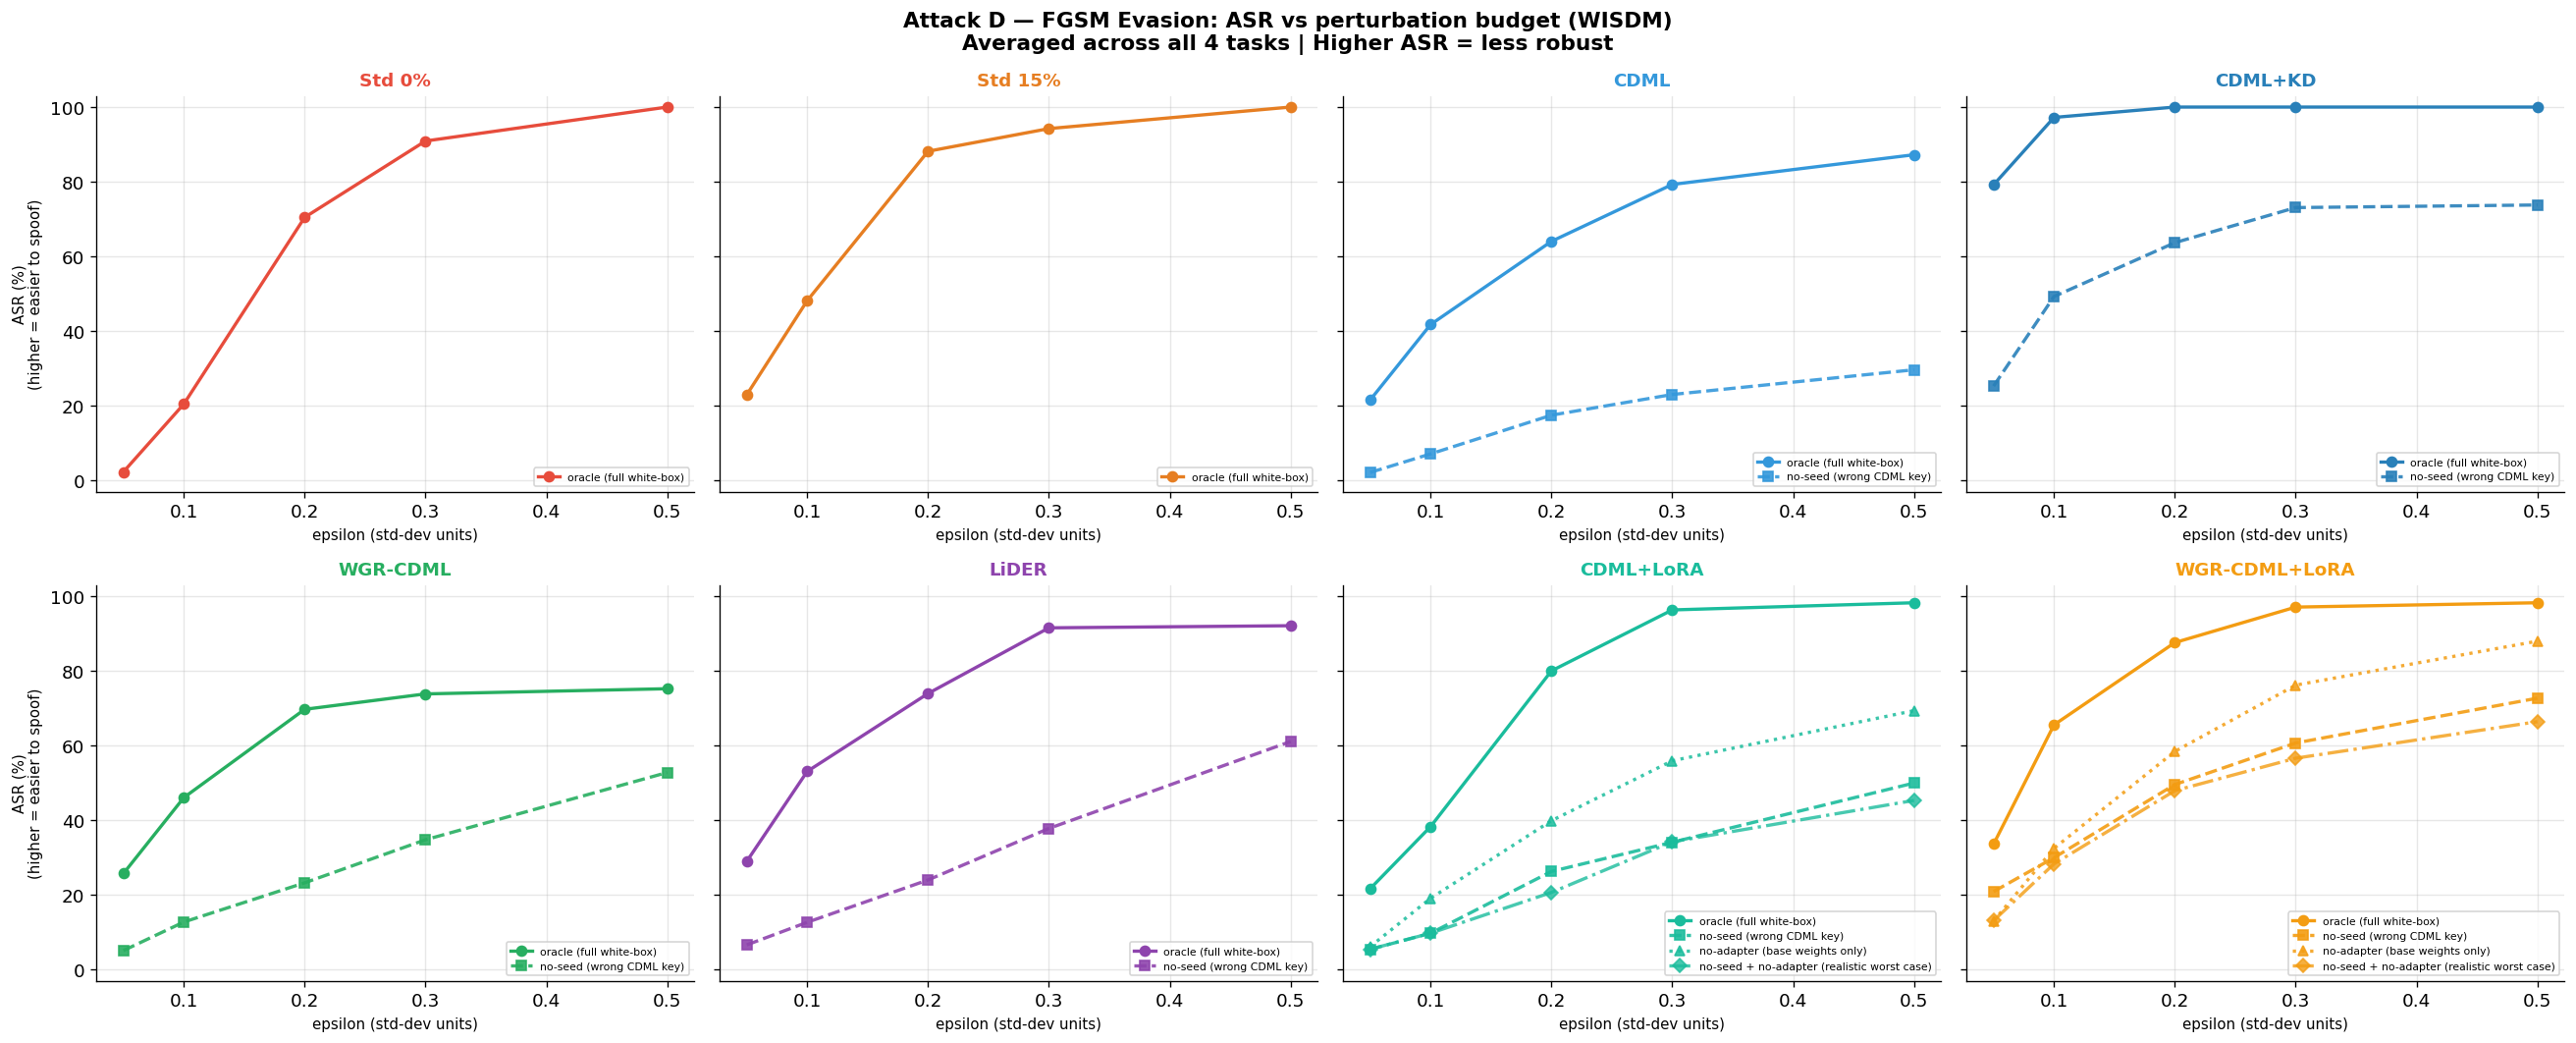

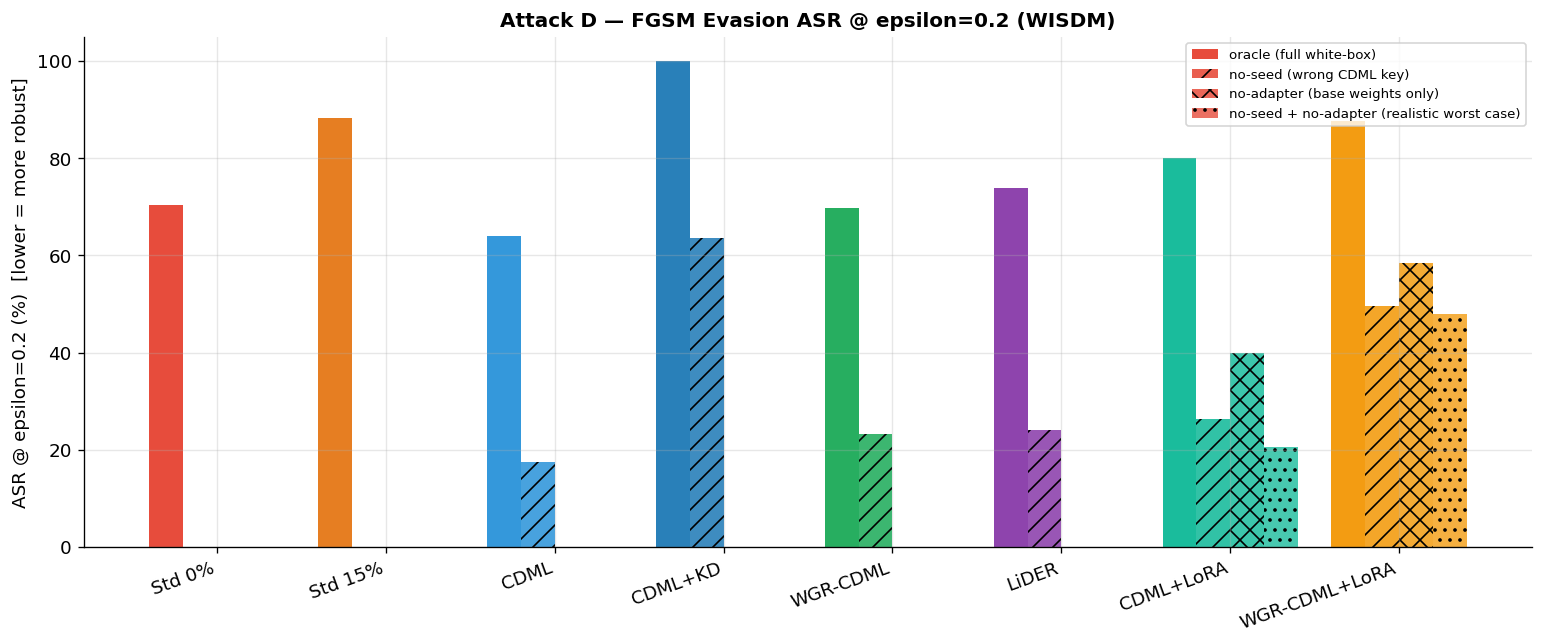

── FGSM Evasion ASR @ epsilon=0.2 (mean over 4 tasks) ──
  Std 0%              oracle (full white-box):  70.5%
  Std 15%             oracle (full white-box):  88.2%
  CDML                oracle (full white-box):  64.0%  |  no-seed (wrong CDML key):  17.5%
  CDML+KD             oracle (full white-box): 100.0%  |  no-seed (wrong CDML key):  63.7%
  WGR-CDML            oracle (full white-box):  69.7%  |  no-seed (wrong CDML key):  23.2%
  LiDER               oracle (full white-box):  74.0%  |  no-seed (wrong CDML key):  24.0%
  CDML+LoRA           oracle (full white-box):  80.0%  |  no-seed (wrong CDML key):  26.3%  |  no-adapter (base weights only):  39.9%  |  no-seed + no-adapter (realistic worst case):  20.7%
  WGR-CDML+LoRA       oracle (full white-box):  87.6%  |  no-seed (wrong CDML key):  49.6%  |  no-adapter (base weights only):  58.4%  |  no-seed + no-adapter (realistic worst case):  47.9%


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9), sharey=True)
axes = axes.flatten()

for ax, (label, model, _, is_cdml, is_lora, color) in zip(axes, MODEL_REGISTRY):
    res = fgsm_evasion_results[label]
    for cond in get_conditions(is_cdml, is_lora):
        mean_curve = np.nanmean([res[cond][t] for t in task_names], axis=0) * 100
        style = CONDITION_STYLE[cond]
        ax.plot(FGSM_EVASION_EPSILONS, mean_curve, color=color,
                lw=2, ls=style['ls'], marker=style['marker'], ms=6,
                alpha=style['alpha'], label=CONDITION_LABEL[cond])
    ax.set_xlabel('epsilon (std-dev units)', fontsize=9)
    ax.set_title(label, color=color, fontsize=11, fontweight='bold')
    ax.set_ylim(-3, 103)
    ax.legend(fontsize=6.5, loc='lower right')

for ax in (axes[0], axes[4]):
    ax.set_ylabel('ASR (%)\n(higher = easier to spoof)', fontsize=9)

plt.suptitle(f'Attack D — FGSM Evasion: ASR vs perturbation budget (WISDM)\n'
             'Averaged across all 4 tasks | Higher ASR = less robust',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fgsm_evasion.png', bbox_inches='tight')
plt.show()

# ── ASR summary bar chart at a representative epsilon ─────────────────────
REPORT_EPS = 0.2
eps_i = FGSM_EVASION_EPSILONS.index(REPORT_EPS)

fig, ax = plt.subplots(figsize=(13, 5.5))
model_labels = [l for l, *_ in MODEL_REGISTRY]
all_conds    = ['oracle', 'no_seed', 'no_adapter', 'no_seed_no_adapter']
x   = np.arange(len(model_labels))
n_c = len(all_conds)
w   = 0.8 / n_c
hatches = ['', '//', 'xx', '..']
for ci, cond in enumerate(all_conds):
    vals = []
    for label, model, _, is_cdml, is_lora, color in MODEL_REGISTRY:
        res = fgsm_evasion_results[label]
        vals.append(np.nanmean([res[cond][t][eps_i] for t in task_names]) * 100
                    if cond in res else np.nan)
    style = CONDITION_STYLE[cond]
    ax.bar(x + (ci - (n_c-1)/2)*w, vals, w, label=CONDITION_LABEL[cond],
           color=[c for *_, c in MODEL_REGISTRY], alpha=style['alpha'], hatch=hatches[ci])
ax.set_xticks(x); ax.set_xticklabels(model_labels, rotation=20, ha='right')
ax.set_ylabel(f'ASR @ epsilon={REPORT_EPS} (%)  [lower = more robust]')
ax.set_title(f'Attack D — FGSM Evasion ASR @ epsilon={REPORT_EPS} (WISDM)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig_fgsm_evasion_bar.png', bbox_inches='tight')
plt.show()

print(f'── FGSM Evasion ASR @ epsilon={REPORT_EPS} (mean over 4 tasks) ──')
for label, model, _, is_cdml, is_lora, _ in MODEL_REGISTRY:
    res = fgsm_evasion_results[label]
    row = []
    for cond in get_conditions(is_cdml, is_lora):
        mean_asr = np.nanmean([res[cond][t][eps_i] for t in task_names]) * 100
        row.append(f'{CONDITION_LABEL[cond]}: {mean_asr:5.1f}%')
    print(f'  {label:<18}  ' + '  |  '.join(row))


## 10. Summary

In [17]:
print('=' * 72)
print('SUMMARY — Attack D (FGSM Evasion), WISDM')
print('=' * 72)

print(f'\nASR @ epsilon={REPORT_EPS} (realistic attacker per model)')
print(f'{"Model":<18} {"ASR":>8}   {"Robust?":>10}')
print('─' * 45)
for label, model, _, is_cdml, is_lora, _ in MODEL_REGISTRY:
    cond   = realistic_condition(is_cdml, is_lora)
    asr    = np.nanmean([fgsm_evasion_results[label][cond][t][eps_i] for t in task_names]) * 100
    robust = '✓ YES' if asr < 30 else ('~ PARTIAL' if asr < 60 else '✗ NO')
    print(f'{label:<18} {asr:>7.1f}%   {robust:>10}')

print(f'\n{"━"*72}')
print('Attacker-knowledge axis breakdown (all conditions)')
print('─' * 72)
for label, model, _, is_cdml, is_lora, _ in MODEL_REGISTRY:
    print(f'\n  {label}:')
    for cond in get_conditions(is_cdml, is_lora):
        asr = np.nanmean([fgsm_evasion_results[label][cond][t][eps_i] for t in task_names]) * 100
        print(f'    {CONDITION_LABEL[cond]:<42} ASR@{REPORT_EPS}={asr:5.1f}%')


SUMMARY — Attack D (FGSM Evasion), WISDM

ASR @ epsilon=0.2 (realistic attacker per model)
Model                   ASR      Robust?
─────────────────────────────────────────────
Std 0%                70.5%         ✗ NO
Std 15%               88.2%         ✗ NO
CDML                  17.5%        ✓ YES
CDML+KD               63.7%         ✗ NO
WGR-CDML              23.2%        ✓ YES
LiDER                 24.0%        ✓ YES
CDML+LoRA             20.7%        ✓ YES
WGR-CDML+LoRA         47.9%    ~ PARTIAL

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Attacker-knowledge axis breakdown (all conditions)
────────────────────────────────────────────────────────────────────────

  Std 0%:
    oracle (full white-box)                    ASR@0.2= 70.5%

  Std 15%:
    oracle (full white-box)                    ASR@0.2= 88.2%

  CDML:
    oracle (full white-box)                    ASR@0.2= 64.0%
    no-seed (wrong CDML key)                   ASR@0.2= 17.5%

  CDML+KD:
    